# Prepoznavanje emocija iz teksta

Finalna demo sveska projekta iz Mašinskog učenja.

**Članovi tima:**  
- Sonja Mijailović  
- Matija Stanković  
- Dimitrije Vranić  

Cilj projekta je klasifikacija tekstova u šest emocija: `joy`, `sadness`, `anger`, `fear`, `love` i `surprise`.

U projektu se porede klasične metode mašinskog učenja, LSTM, GRU i transformer model.

## 1. Učitavanje biblioteka

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display, Image

## 2. Kratak pregled skupa podataka

Koriste se odvojeni trening, validacioni i test skup.  
Pre modelovanja su provereni nedostajući podaci, duplikati i preklapanja između skupova.

In [3]:
train = pd.read_csv("data/processed/train.txt", sep=";", header=None, names=["text", "emotion"])
val = pd.read_csv("data/processed/val.txt", sep=";", header=None, names=["text", "emotion"])
test = pd.read_csv("data/processed/test.txt", sep=";", header=None, names=["text", "emotion"])

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

Train: (15983, 2)
Validation: (1997, 2)
Test: (2000, 2)


### Raspodela emocija u trening skupu

Pošto klase nisu potpuno izbalansirane, pored Accuracy metrike koristimo i **Macro F1**, koji svakoj klasi daje jednaku važnost.

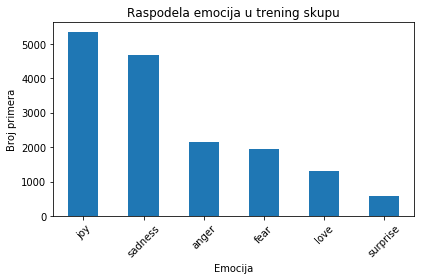

In [4]:
train["emotion"].value_counts().plot(kind="bar")
plt.xlabel("Emocija")
plt.ylabel("Broj primera")
plt.title("Raspodela emocija u trening skupu")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Klasični modeli

Tekstovi su predstavljeni pomoću TF-IDF reprezentacije.

Isprobani su:
- Logistic Regression
- Multinomial Naive Bayes
- Linear SVM
- Random Forest

### Rezultati osnovnih klasičnih modela

In [14]:
baseline_results = pd.read_csv("results/comparable_results/baseline_results.csv")
display(baseline_results)

,model,accuracy,macro_f1
0,Logistic Regression,0.8603,0.8109
1,Naive Bayes,0.6415,0.3548
2,Linear SVM,0.9009,0.8734
3,Random Forest,0.8753,0.8499


Najbolje osnovne rezultate imao je Linear SVM, pa su za najperspektivnije modele dodatno podešavani hiperparametri pomoću `GridSearchCV`.

### Rezultati podešavanja hiperparametara

GridSearchCV je izvođen samo na trening skupu, uz 3-fold unakrsnu validaciju.  
Poseban validacioni skup je zatim korišćen za poređenje najboljih podešenih modela.

In [15]:
tuned_results = pd.read_csv("results/comparable_results/tuned_results.csv")
display(tuned_results)

,model,accuracy,macro_f1
0,Linear SVM tuned,0.901853,0.879462
1,Logistic Regression tuned,0.894842,0.870970


Za Linear SVM najbolji hiperparametri bili su:

- `C = 0.5`
- `class_weight = "balanced"`
- `ngram_range = (1, 1)`

Nakon izbora modela, trening i validacioni skup su spojeni i finalni SVM je obučen na njihovoj uniji.  
Test skup je korišćen samo za konačnu evaluaciju.

## 4. Konačni rezultat klasičnog modela

In [12]:
final_results = pd.read_csv("results/comparable_results/final_results.csv")

final_classical = final_results[
    final_results["model"] == "Linear SVM"
]

display(final_classical)

,model,accuracy,macro_f1
0,Linear SVM,0.897,0.8536


Konačni Linear SVM ostvario je približno:

- Accuracy = **0.897**
- Macro F1 = **0.854**

### Matrica konfuzije finalnog SVM modela

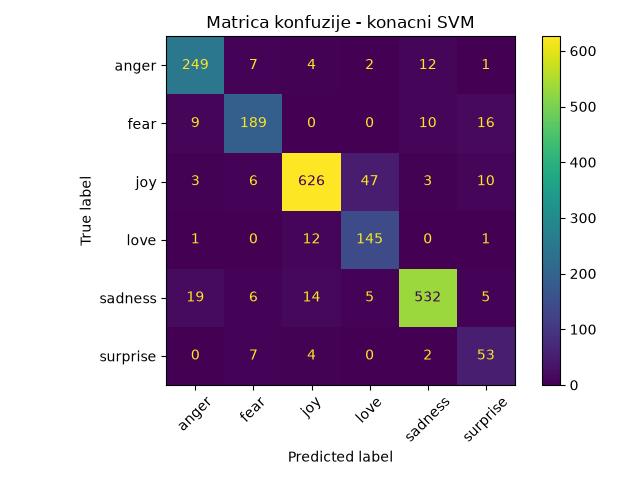

In [9]:
display(Image(filename="results/SVM/confusion_matrix_final_svm.png"))

## 5. Demonstracija predikcija finalnog SVM modela

Učitava se već sačuvani Pipeline, koji sadrži TF-IDF vektorizator i Linear SVM.

In [10]:
model = joblib.load("models/final_svm.joblib")
print("Finalni SVM model je učitan.")

Finalni SVM model je učitan.


In [11]:
primeri = [
    "i feel very happy today",
    "i am scared about what will happen",
    "i feel deeply sad and lonely",
    "i am so angry right now"
]

predikcije = model.predict(primeri)

for tekst, emocija in zip(primeri, predikcije):
    print(tekst, "->", emocija)

i feel very happy today -> joy
i am scared about what will happen -> fear
i feel deeply sad and lonely -> sadness
i am so angry right now -> anger


## 6. LSTM


## 7. Transformer model


## 8. Poređenje svih modela


,model,accuracy,macro_f1
0,Linear SVM,0.8970,0.853600
1,BERT,0.9310,0.890937
2,DistilBERT,0.9320,0.889258
3,LSTM,0.9035,0.865920
4,GRU,0.9060,0.857017


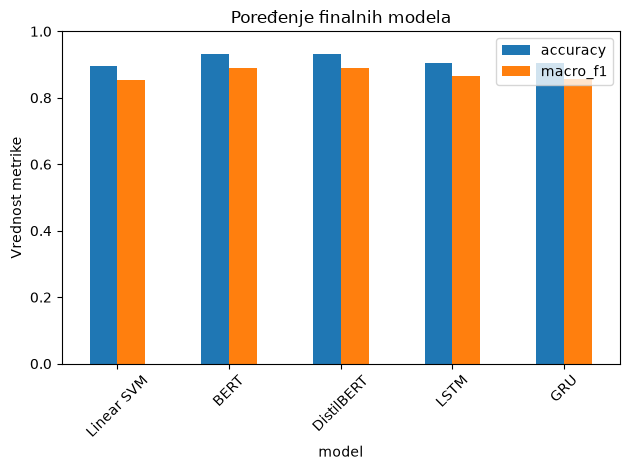

In [9]:
final_results = pd.read_csv("results/comparable_results/final_results.csv")
display(final_results)

final_results.set_index("model")[["accuracy", "macro_f1"]].plot(kind="bar")
plt.ylabel("Vrednost metrike")
plt.title("Poređenje finalnih modela")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 9. Zaključak
